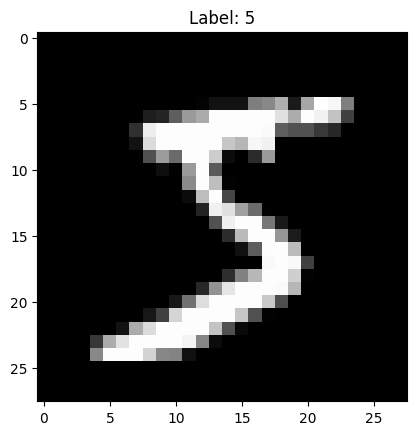

Epoch 1, Loss: 2.2890
Epoch 2, Loss: 2.2212
Epoch 3, Loss: 2.1546
Epoch 4, Loss: 2.0874
Epoch 5, Loss: 2.0190
Epoch 6, Loss: 1.9495
Epoch 7, Loss: 1.8793
Epoch 8, Loss: 1.8089
Epoch 9, Loss: 1.7384
Epoch 10, Loss: 1.6683
Test Accuracy: 0.7464


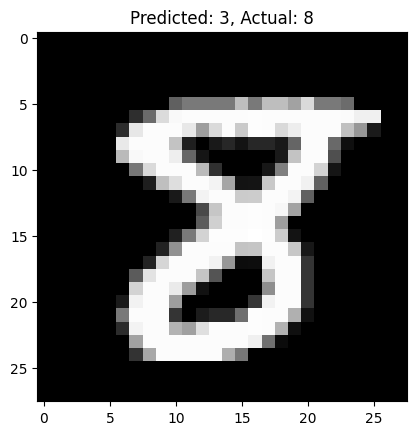

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim

# Load data (using sklearn's wrapper)
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(np.uint8)

# Display sample image using matplotlib
plt.imshow(X[0].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y[0]}")
plt.show()

# Split data (using pandas for demonstration, though not necessary)
df = pd.DataFrame(X)
df['label'] = y
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Prepare PyTorch tensors
X_train = torch.tensor(train_df.drop('label', axis=1).values, dtype=torch.float32) / 255.0
y_train = torch.tensor(train_df['label'].values, dtype=torch.long)
X_test = torch.tensor(test_df.drop('label', axis=1).values, dtype=torch.float32) / 255.0
y_test = torch.tensor(test_df['label'].values, dtype=torch.long)

# Simple neural network
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 10)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

# Training loop
for epoch in range(10):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# Evaluation
with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)
    accuracy = (predicted == y_test).sum().item() / y_test.size(0)
    print(f"Test Accuracy: {accuracy:.4f}")

# Display a test prediction
sample_idx = 0
with torch.no_grad():
    sample = X_test[sample_idx].unsqueeze(0)
    prediction = torch.argmax(model(sample)).item()

plt.imshow(X_test[sample_idx].reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {prediction}, Actual: {y_test[sample_idx]}")
plt.show()